In [1]:
# ============================================================
# CELL 1 — IMPORTS & LOAD DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.preprocessing     import StandardScaler
from sklearn.cluster           import KMeans, DBSCAN
from sklearn.decomposition     import PCA
from sklearn.metrics           import silhouette_score, silhouette_samples
from sklearn.ensemble          import RandomForestClassifier
from sklearn.model_selection   import cross_val_score
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance    import cdist

# ── Plot Style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0F1117',
    'axes.facecolor':    '#1A1D27',
    'axes.edgecolor':    '#2E3250',
    'axes.labelcolor':   '#E0E0E0',
    'axes.titlecolor':   '#FFFFFF',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.color':       '#A0A0A0',
    'ytick.color':       '#A0A0A0',
    'text.color':        '#E0E0E0',
    'grid.color':        '#2E3250',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'legend.facecolor':  '#1A1D27',
    'legend.edgecolor':  '#2E3250',
})

COLORS = {
    'star':       '#00D4AA',
    'stable':     '#4A90D9',
    'new':        '#F5A623',
    'struggling': '#E8724A',
    'critical':   '#E84A4A',
}

CLUSTER_COLORS = ['#00D4AA', '#4A90D9', '#F5A623', '#E84A4A', '#9B59B6']

# Paths
processed_path = r'D:\Projects\End-to-end projects\12. Franchise Intelligence System\Data\Processed'
chart_path     = r'D:\Projects\End-to-end projects\12. Franchise Intelligence System\Reports'

# Load outlet scores
outlet_scores = pd.read_csv(f'{processed_path}\\outlet_scores.csv')

print("✅ Libraries loaded successfully")
print(f"outlet_scores shape: {outlet_scores.shape}")
print(f"\nColumns available:\n{list(outlet_scores.columns)}")

✅ Libraries loaded successfully
outlet_scores shape: (85, 29)

Columns available:
['outlet_id', 'city', 'tier', 'archetype', 'outlet_type', 'zone', 'outlet_age_months', 'total_revenue_18m', 'avg_monthly_revenue', 'avg_monthly_orders', 'avg_order_value', 'avg_net_margin_pct', 'avg_contribution_pct', 'avg_food_cost_pct', 'avg_rating', 'avg_complaint_rate', 'avg_repeat_pct', 'avg_waste_rate', 'avg_upsell_rate', 'avg_staff_turnover', 'total_manager_changes', 'avg_training_hours', 'last_3m_avg_revenue', 'first_3m_avg_revenue', 'revenue_trend_pct', 'composite_score', 'performance_rank', 'performance_tier', 'intervention_action']


In [2]:
# ============================================================
# CELL 2 — FEATURE SELECTION & SCALING
# ============================================================

# Select 15 KPI features for clustering
# These cover all 4 dimensions: Revenue, Margin, Customer, Operations
feature_cols = [
    # Revenue dimension
    'avg_monthly_revenue',
    'avg_monthly_orders',
    'avg_order_value',
    'revenue_trend_pct',
    # Margin dimension
    'avg_net_margin_pct',
    'avg_contribution_pct',
    'avg_food_cost_pct',
    # Customer dimension
    'avg_rating',
    'avg_complaint_rate',
    'avg_repeat_pct',
    'avg_upsell_rate',
    # Operations dimension
    'avg_waste_rate',
    'avg_staff_turnover',
    'avg_training_hours',
    'total_manager_changes',
]

# Extract feature matrix
X = outlet_scores[feature_cols].copy()

# Check for nulls
print("Null values per feature:")
print(X.isnull().sum())
print(f"\nFeature matrix shape: {X.shape}")

# Fill any nulls with median
X = X.fillna(X.median())

# Scale features — critical for clustering
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"\n✅ Features scaled successfully")
print(f"Scaled matrix shape : {X_scaled.shape}")
print(f"\nFeature means after scaling (should be ~0):")
print(X_scaled.mean().round(3))
print(f"\nFeature stds after scaling (should be ~1):")
print(X_scaled.std().round(3))

Null values per feature:
avg_monthly_revenue      0
avg_monthly_orders       0
avg_order_value          0
revenue_trend_pct        0
avg_net_margin_pct       0
avg_contribution_pct     0
avg_food_cost_pct        0
avg_rating               0
avg_complaint_rate       0
avg_repeat_pct           0
avg_upsell_rate          0
avg_waste_rate           0
avg_staff_turnover       0
avg_training_hours       0
total_manager_changes    0
dtype: int64

Feature matrix shape: (85, 15)

✅ Features scaled successfully
Scaled matrix shape : (85, 15)

Feature means after scaling (should be ~0):
avg_monthly_revenue      0.0
avg_monthly_orders      -0.0
avg_order_value          0.0
revenue_trend_pct        0.0
avg_net_margin_pct      -0.0
avg_contribution_pct    -0.0
avg_food_cost_pct       -0.0
avg_rating              -0.0
avg_complaint_rate       0.0
avg_repeat_pct          -0.0
avg_upsell_rate          0.0
avg_waste_rate          -0.0
avg_staff_turnover      -0.0
avg_training_hours      -0.0
total_manag

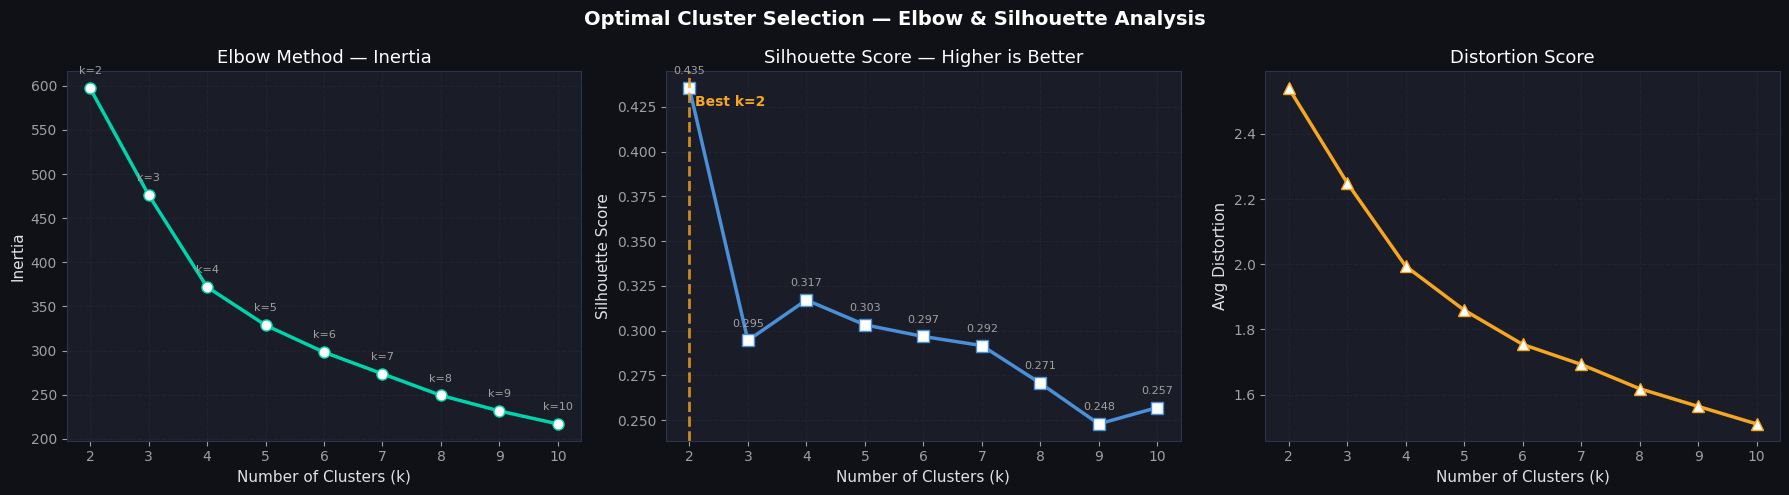


📊 CLUSTER SELECTION RESULTS
  k=2  |  Inertia:    597.4  |  Silhouette: 0.4354 ← BEST
  k=3  |  Inertia:    476.6  |  Silhouette: 0.2945
  k=4  |  Inertia:    372.1  |  Silhouette: 0.3171
  k=5  |  Inertia:    328.8  |  Silhouette: 0.3033
  k=6  |  Inertia:    298.1  |  Silhouette: 0.2967
  k=7  |  Inertia:    273.6  |  Silhouette: 0.2917
  k=8  |  Inertia:    249.1  |  Silhouette: 0.2707
  k=9  |  Inertia:    231.5  |  Silhouette: 0.2479
  k=10  |  Inertia:    216.8  |  Silhouette: 0.2571

✅ Optimal k = 2 based on Silhouette Score


In [3]:
# ============================================================
# CELL 3 — ELBOW METHOD & SILHOUETTE ANALYSIS
# Finding the optimal number of clusters statistically
# ============================================================

k_range         = range(2, 11)
inertias        = []
silhouette_scores = []
distortions     = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42,
                    n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))
    distortions.append(sum(np.min(
        cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'),
        axis=1)) / X_scaled.shape[0])

# ── Plot Elbow & Silhouette ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Optimal Cluster Selection — Elbow & Silhouette Analysis',
             fontsize=14, fontweight='bold', color='white')

# Plot 1: Elbow Curve
ax1 = axes[0]
ax1.plot(list(k_range), inertias,
         color='#00D4AA', linewidth=2.5,
         marker='o', markersize=8,
         markerfacecolor='white', markeredgecolor='#00D4AA')
ax1.set_title('Elbow Method — Inertia', color='white')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.grid(True, alpha=0.3)
for k, v in zip(k_range, inertias):
    ax1.annotate(f'k={k}', (k, v),
                 textcoords='offset points',
                 xytext=(0, 10), ha='center',
                 color='#A0A0A0', fontsize=8)

# Plot 2: Silhouette Score
ax2 = axes[1]
ax2.plot(list(k_range), silhouette_scores,
         color='#4A90D9', linewidth=2.5,
         marker='s', markersize=8,
         markerfacecolor='white', markeredgecolor='#4A90D9')
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=best_k, color='#F5A623',
            linestyle='--', linewidth=2, alpha=0.8)
ax2.set_title('Silhouette Score — Higher is Better', color='white')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)
for k, v in zip(k_range, silhouette_scores):
    ax2.annotate(f'{v:.3f}', (k, v),
                 textcoords='offset points',
                 xytext=(0, 10), ha='center',
                 color='#A0A0A0', fontsize=8)
ax2.text(best_k + 0.1, max(silhouette_scores) - 0.01,
         f'Best k={best_k}', color='#F5A623',
         fontsize=10, fontweight='bold')

# Plot 3: Distortion Score
ax3 = axes[2]
ax3.plot(list(k_range), distortions,
         color='#F5A623', linewidth=2.5,
         marker='^', markersize=8,
         markerfacecolor='white', markeredgecolor='#F5A623')
ax3.set_title('Distortion Score', color='white')
ax3.set_xlabel('Number of Clusters (k)')
ax3.set_ylabel('Avg Distortion')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{chart_path}\\chart_11_cluster_selection.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()

print(f"\n📊 CLUSTER SELECTION RESULTS")
print(f"{'='*45}")
for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    marker = ' ← BEST' if k == best_k else ''
    print(f"  k={k}  |  Inertia: {inertia:8.1f}  |  Silhouette: {sil:.4f}{marker}")
print(f"\n✅ Optimal k = {best_k} based on Silhouette Score")

In [4]:
# ============================================================
# CELL 4 — K-MEANS CLUSTERING WITH k=4
# Business decision: k=4 for interpretable segmentation
# Statistical note: k=2 maximizes silhouette but provides
# insufficient business granularity for intervention planning
# ============================================================

OPTIMAL_K = 4

# Fit final K-Means model
kmeans_final = KMeans(
    n_clusters = OPTIMAL_K,
    random_state = 42,
    n_init = 20,
    max_iter = 500
)
kmeans_final.fit(X_scaled)

# Add cluster labels to outlet_scores
outlet_scores['cluster'] = kmeans_final.labels_

# Cluster sizes
print("📊 CLUSTER SIZES:")
print(outlet_scores['cluster'].value_counts().sort_index())

# Cluster profiles — mean of each feature per cluster
cluster_profile = outlet_scores.groupby('cluster')[feature_cols].mean().round(2)
print(f"\n📊 CLUSTER PROFILES — MEAN KPIs:")
print(cluster_profile.T.to_string())

# Silhouette score for k=4
sil_k4 = silhouette_score(X_scaled, kmeans_final.labels_)
print(f"\nSilhouette Score for k=4 : {sil_k4:.4f}")

# Map clusters to business labels based on composite score
cluster_composite = outlet_scores.groupby('cluster')['composite_score'].mean().sort_values(ascending=False)
print(f"\n📊 CLUSTER COMPOSITE SCORES (sorted):")
print(cluster_composite.round(2))

# Assign business labels based on composite score rank
cluster_rank = cluster_composite.rank(ascending=False).astype(int)
cluster_label_map = {}
label_map = {1: 'Cluster A — Star Performers',
             2: 'Cluster B — Stable Operators',
             3: 'Cluster C — Needs Improvement',
             4: 'Cluster D — Critical Risk'}
for cluster_id, rank in cluster_rank.items():
    cluster_label_map[cluster_id] = label_map[rank]

outlet_scores['cluster_label'] = outlet_scores['cluster'].map(cluster_label_map)

print(f"\n📊 CLUSTER LABEL MAPPING:")
for k, v in cluster_label_map.items():
    count = (outlet_scores['cluster'] == k).sum()
    score = cluster_composite[k]
    print(f"  Cluster {k} → {v} | Outlets: {count} | Avg Score: {score:.1f}")

📊 CLUSTER SIZES:
cluster
0    25
1    25
2     9
3    26
Name: count, dtype: int64

📊 CLUSTER PROFILES — MEAN KPIs:
cluster                        0          1         2          3
avg_monthly_revenue    120638.92  345950.44  71876.89  228979.77
avg_monthly_orders        273.32     699.88    155.56     467.62
avg_order_value           433.28     484.88    450.67     477.27
revenue_trend_pct          -4.85      -5.83     -4.81      -5.72
avg_net_margin_pct        -25.96      18.17    -91.52       3.67
avg_contribution_pct       41.44      45.67     39.29      44.66
avg_food_cost_pct          31.52      31.51     31.48      31.53
avg_rating                  3.57       4.28      3.10       3.94
avg_complaint_rate         14.34       7.05     19.16      10.45
avg_repeat_pct             43.71      56.53     35.11      50.07
avg_upsell_rate            28.39      37.50     22.54      33.02
avg_waste_rate             24.26      12.90     30.90      18.53
avg_staff_turnover         11.74       

📊 PCA EXPLAINED VARIANCE:
Component    Individual %     Cumulative %
  PC1            70.50%         70.50%
  PC2             9.20%         79.69% ← 80% threshold
  PC3             6.81%         86.51% ← 90% threshold
  PC4             6.35%         92.86% ← 90% threshold
  PC5             4.91%         97.77%
  PC6             0.81%         98.58%
  PC7             0.44%         99.03%
  PC8             0.31%         99.34%
  PC9             0.28%         99.62%
  PC10            0.19%         99.81%
  PC11            0.07%         99.88%
  PC12            0.06%         99.94%
  PC13            0.04%         99.98%
  PC14            0.02%         99.99%
  PC15            0.01%        100.00%

✅ Components needed for 80% variance: 3
✅ Components needed for 90% variance: 4


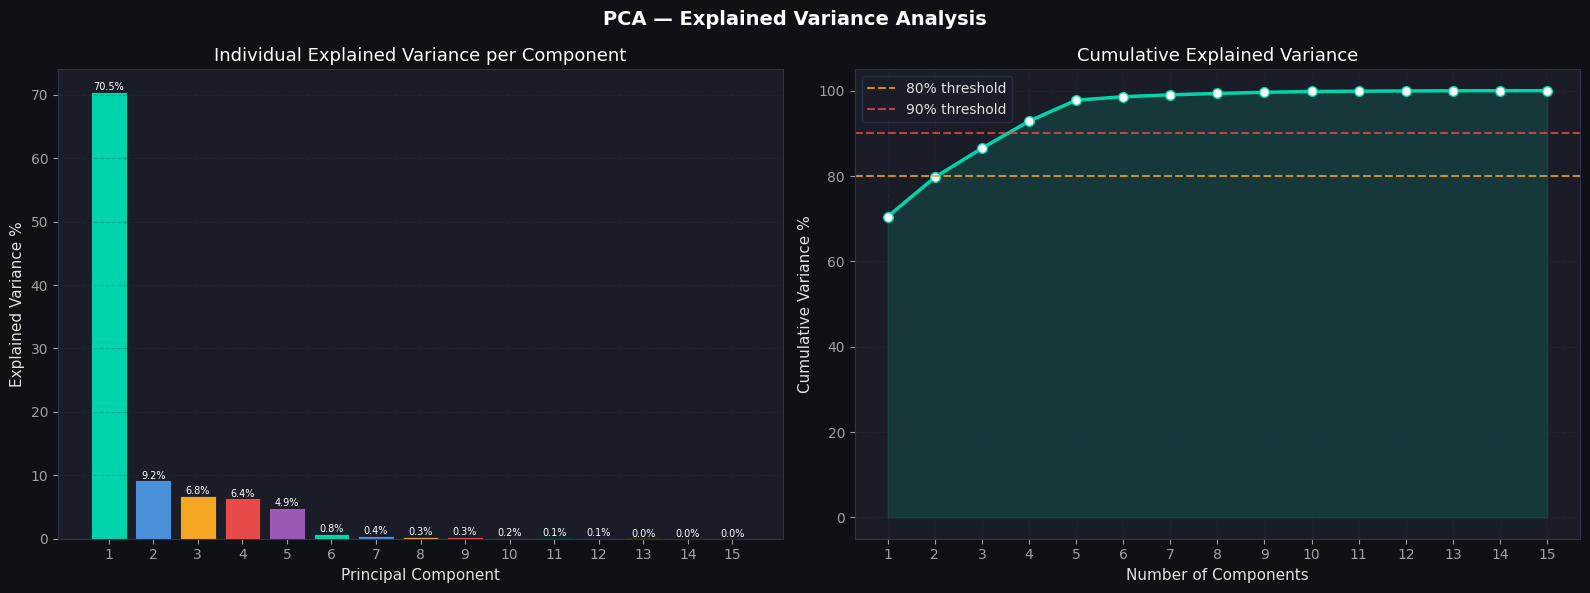


✅ PCA variance chart saved


In [5]:
# ============================================================
# CELL 5 — PCA: DIMENSIONALITY REDUCTION
# Reduce 15 KPIs to 2 dimensions for visualization
# ============================================================

# Fit PCA
pca = PCA(n_components=15, random_state=42)
pca.fit(X_scaled)

# Explained variance
explained_variance     = pca.explained_variance_ratio_
cumulative_variance    = np.cumsum(explained_variance)

print("📊 PCA EXPLAINED VARIANCE:")
print(f"{'Component':<12} {'Individual %':<16} {'Cumulative %'}")
print("="*42)
for i, (ind, cum) in enumerate(zip(explained_variance, cumulative_variance)):
    marker = ' ← 80% threshold' if abs(cum - 0.80) < 0.05 else ''
    marker = ' ← 90% threshold' if abs(cum - 0.90) < 0.05 else marker
    print(f"  PC{i+1:<9} {ind*100:>8.2f}%      {cum*100:>8.2f}%{marker}")

# How many components explain 80% variance
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\n✅ Components needed for 80% variance: {n_components_80}")
print(f"✅ Components needed for 90% variance: {n_components_90}")

# ── Plot: Explained Variance ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA — Explained Variance Analysis',
             fontsize=14, fontweight='bold', color='white')

# Plot 1: Individual variance
ax1 = axes[0]
bars = ax1.bar(range(1, 16), explained_variance * 100,
               color=CLUSTER_COLORS * 3,
               edgecolor='#0F1117', linewidth=0.5)
for bar, val in zip(bars, explained_variance * 100):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center',
             color='white', fontsize=7)
ax1.set_title('Individual Explained Variance per Component',
              color='white')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance %')
ax1.set_xticks(range(1, 16))
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Cumulative variance
ax2 = axes[1]
ax2.plot(range(1, 16), cumulative_variance * 100,
         color='#00D4AA', linewidth=2.5,
         marker='o', markersize=7,
         markerfacecolor='white')
ax2.axhline(y=80, color='#F5A623', linestyle='--',
            linewidth=1.5, alpha=0.8, label='80% threshold')
ax2.axhline(y=90, color='#E84A4A', linestyle='--',
            linewidth=1.5, alpha=0.8, label='90% threshold')
ax2.fill_between(range(1, 16), cumulative_variance * 100,
                 alpha=0.15, color='#00D4AA')
ax2.set_title('Cumulative Explained Variance', color='white')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance %')
ax2.set_xticks(range(1, 16))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{chart_path}\\chart_12_pca_variance.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("\n✅ PCA variance chart saved")

📊 PCA LOADINGS — Feature Contributions:
                         PC1    PC2
avg_rating             0.305 -0.085
avg_repeat_pct         0.304 -0.088
avg_upsell_rate        0.304 -0.088
avg_contribution_pct   0.300 -0.071
avg_training_hours     0.299 -0.088
avg_monthly_orders     0.290  0.242
avg_net_margin_pct     0.285 -0.195
avg_monthly_revenue    0.265  0.396
avg_order_value        0.100  0.722
avg_food_cost_pct      0.023 -0.261
revenue_trend_pct     -0.038 -0.250
total_manager_changes -0.154 -0.161
avg_staff_turnover    -0.296  0.132
avg_complaint_rate    -0.304  0.086
avg_waste_rate        -0.304  0.090

PC1 explains: 70.5%
PC2 explains: 9.2%


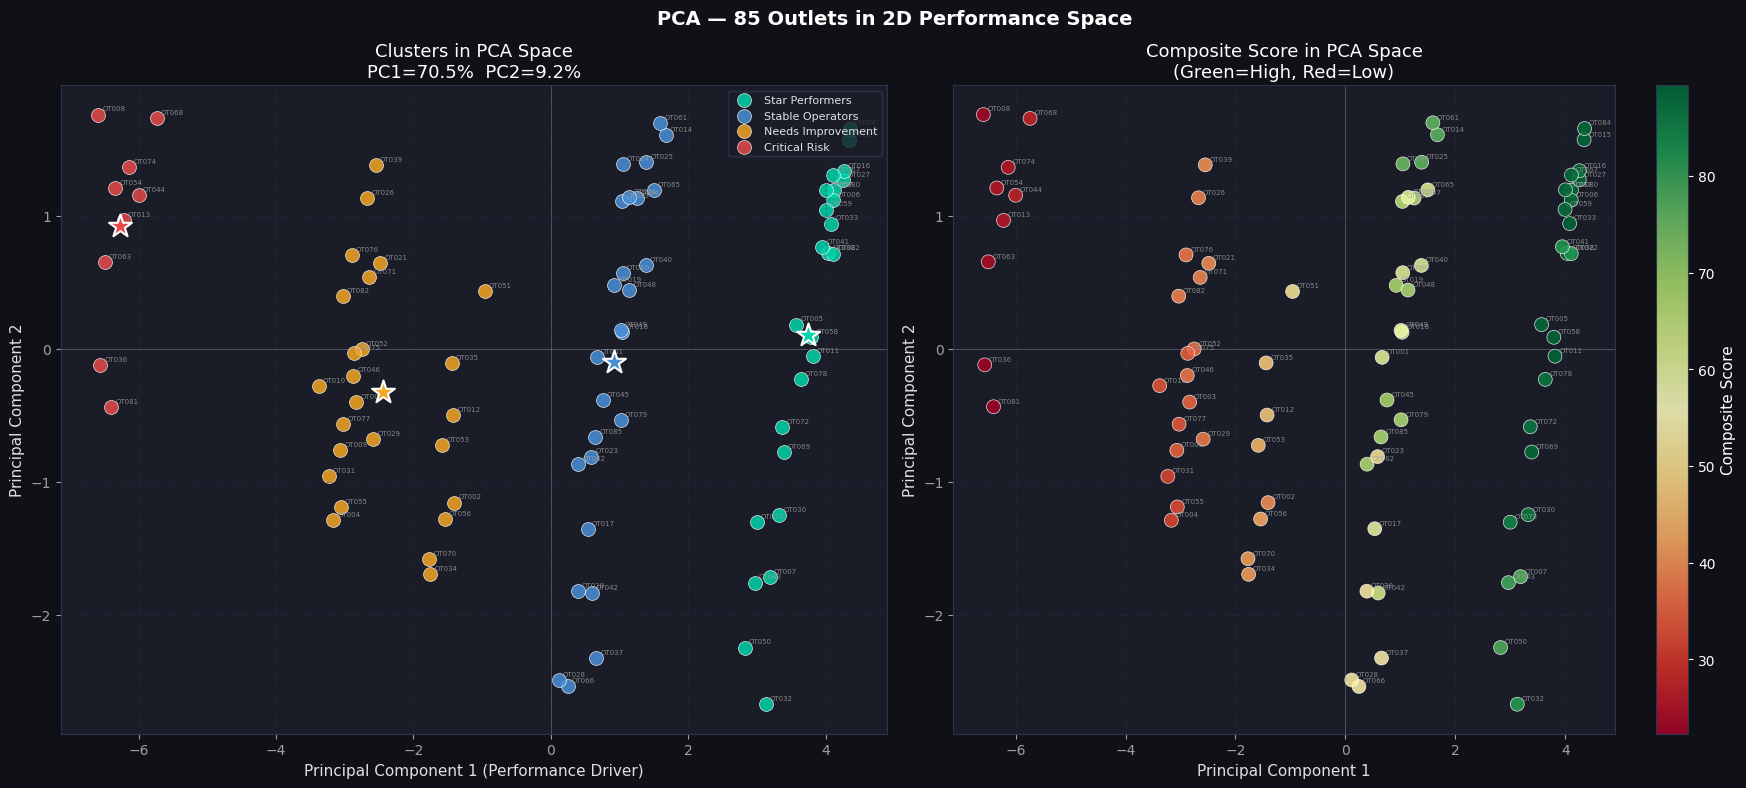

✅ PCA cluster chart saved


In [6]:
# ============================================================
# CELL 6 — PCA 2D VISUALIZATION
# Project all 85 outlets onto 2D space
# ============================================================

# Fit PCA with 2 components for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_scaled)

# Add PCA coordinates to outlet_scores
outlet_scores['pca_1'] = X_pca[:, 0]
outlet_scores['pca_2'] = X_pca[:, 1]

# PCA loadings — which features drive each component
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
).round(3)

print("📊 PCA LOADINGS — Feature Contributions:")
print("="*50)
print(loadings.sort_values('PC1', ascending=False).to_string())
print(f"\nPC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")

# ── Plot 1: PCA by Cluster Label ───────────────────────────
cluster_color_map = {
    'Cluster A — Star Performers':    '#00D4AA',
    'Cluster B — Stable Operators':   '#4A90D9',
    'Cluster C — Needs Improvement':  '#F5A623',
    'Cluster D — Critical Risk':      '#E84A4A',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('PCA — 85 Outlets in 2D Performance Space',
             fontsize=14, fontweight='bold', color='white')

# Plot 1: Coloured by cluster
ax1 = axes[0]
for label, color in cluster_color_map.items():
    mask = outlet_scores['cluster_label'] == label
    data = outlet_scores[mask]
    ax1.scatter(data['pca_1'], data['pca_2'],
                color=color, s=100, alpha=0.85,
                label=label.split('—')[1].strip(),
                edgecolors='white', linewidth=0.5)
    for _, row in data.iterrows():
        ax1.annotate(row['outlet_id'],
                     (row['pca_1'], row['pca_2']),
                     fontsize=5, color='#A0A0A0',
                     alpha=0.8,
                     xytext=(3,3),
                     textcoords='offset points')

# Draw cluster centroids
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    cluster_num = i
    label       = cluster_label_map[cluster_num]
    color       = cluster_color_map[label]
    ax1.scatter(cx, cy, color=color, s=300,
                marker='*', edgecolors='white',
                linewidth=1.5, zorder=5)

ax1.set_title(f'Clusters in PCA Space\nPC1={pca_2d.explained_variance_ratio_[0]*100:.1f}%  '
              f'PC2={pca_2d.explained_variance_ratio_[1]*100:.1f}%',
              color='white')
ax1.set_xlabel('Principal Component 1 (Performance Driver)')
ax1.set_ylabel('Principal Component 2')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
ax1.axvline(x=0, color='white', linewidth=0.5, alpha=0.3)

# Plot 2: Coloured by composite score
ax2 = axes[1]
scatter = ax2.scatter(
    outlet_scores['pca_1'],
    outlet_scores['pca_2'],
    c=outlet_scores['composite_score'],
    cmap='RdYlGn',
    s=100, alpha=0.85,
    edgecolors='white', linewidth=0.5
)
for _, row in outlet_scores.iterrows():
    ax2.annotate(row['outlet_id'],
                 (row['pca_1'], row['pca_2']),
                 fontsize=5, color='#A0A0A0',
                 alpha=0.8,
                 xytext=(3,3),
                 textcoords='offset points')
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Composite Score', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
ax2.set_title('Composite Score in PCA Space\n(Green=High, Red=Low)',
              color='white')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)
ax2.axvline(x=0, color='white', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{chart_path}\\chart_13_pca_clusters.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ PCA cluster chart saved")

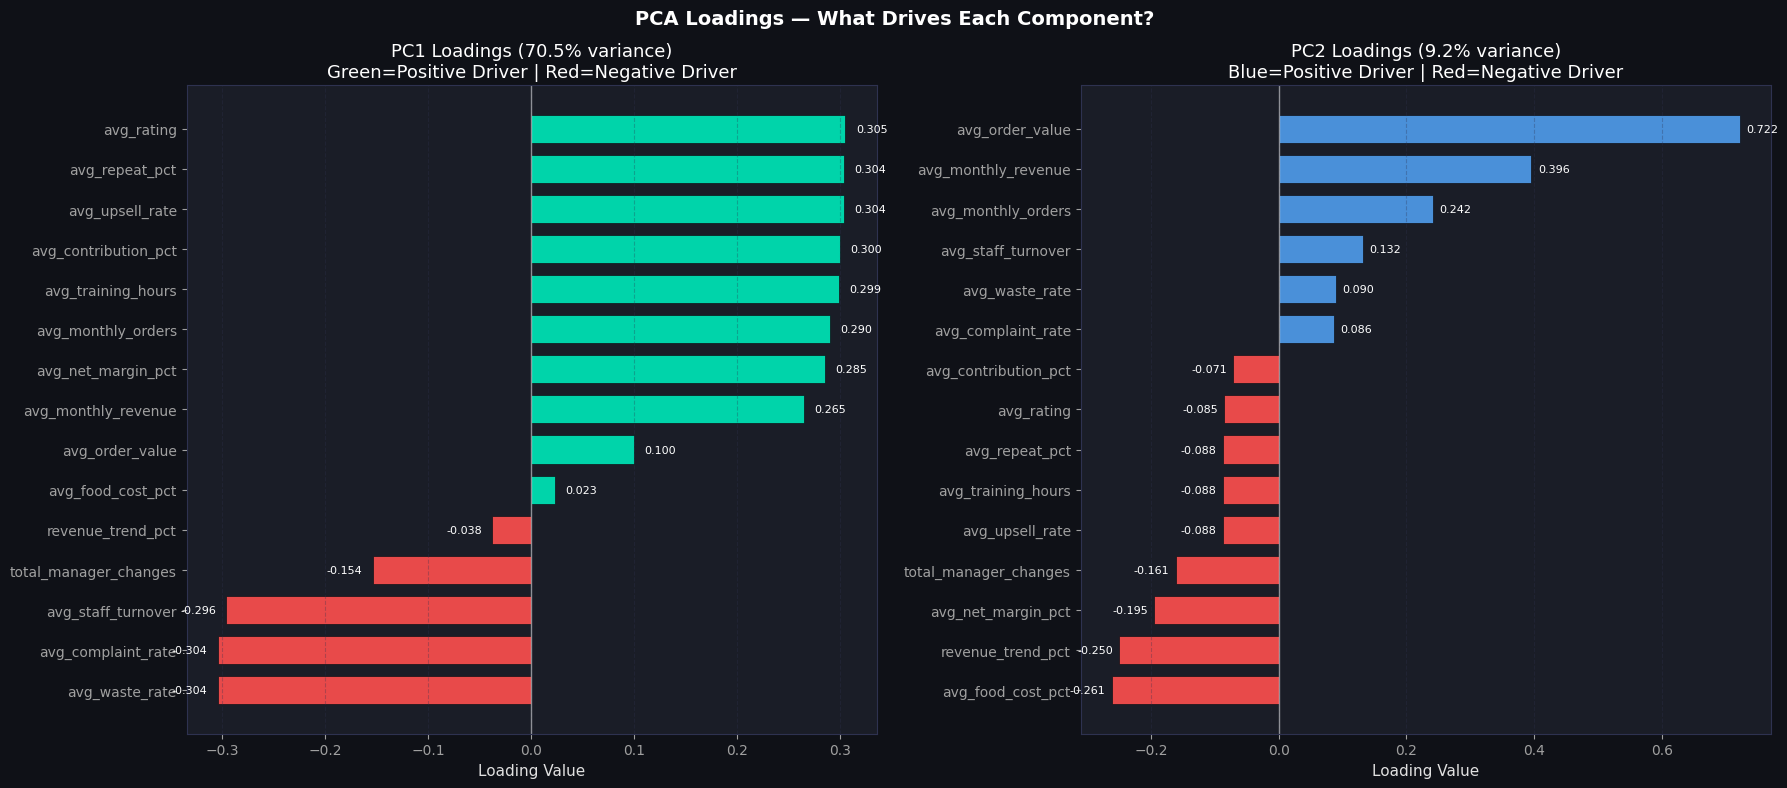

✅ PCA loadings chart saved


In [7]:
# ============================================================
# CELL 7 — PCA LOADINGS BIPLOT
# Which KPIs drive each principal component?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('PCA Loadings — What Drives Each Component?',
             fontsize=14, fontweight='bold', color='white')

# Plot 1: PC1 Loadings
ax1 = axes[0]
pc1_loadings = loadings['PC1'].sort_values(ascending=True)
colors_pc1   = ['#E84A4A' if v < 0 else '#00D4AA'
                for v in pc1_loadings.values]
bars = ax1.barh(pc1_loadings.index,
                pc1_loadings.values,
                color=colors_pc1,
                edgecolor='#0F1117',
                linewidth=0.5, height=0.7)
for bar, val in zip(bars, pc1_loadings.values):
    ax1.text(val + 0.01 if val >= 0 else val - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right',
             color='white', fontsize=8)
ax1.axvline(x=0, color='white', linewidth=1, alpha=0.5)
ax1.set_title(f'PC1 Loadings ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)\n'
              f'Green=Positive Driver | Red=Negative Driver',
              color='white')
ax1.set_xlabel('Loading Value')
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: PC2 Loadings
ax2 = axes[1]
pc2_loadings = loadings['PC2'].sort_values(ascending=True)
colors_pc2   = ['#E84A4A' if v < 0 else '#4A90D9'
                for v in pc2_loadings.values]
bars = ax2.barh(pc2_loadings.index,
                pc2_loadings.values,
                color=colors_pc2,
                edgecolor='#0F1117',
                linewidth=0.5, height=0.7)
for bar, val in zip(bars, pc2_loadings.values):
    ax2.text(val + 0.01 if val >= 0 else val - 0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right',
             color='white', fontsize=8)
ax2.axvline(x=0, color='white', linewidth=1, alpha=0.5)
ax2.set_title(f'PC2 Loadings ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)\n'
              f'Blue=Positive Driver | Red=Negative Driver',
              color='white')
ax2.set_xlabel('Loading Value')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{chart_path}\\chart_14_pca_loadings.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ PCA loadings chart saved")

📊 RANDOM FOREST — CROSS VALIDATION
CV Accuracy scores : [1. 1. 1. 1. 1.]
Mean CV Accuracy   : 1.000
Std CV Accuracy    : 0.000

📊 FEATURE IMPORTANCE RANKING:
              feature  importance
       avg_waste_rate      0.1230
   avg_net_margin_pct      0.1224
   avg_complaint_rate      0.1186
      avg_upsell_rate      0.1169
       avg_repeat_pct      0.1152
           avg_rating      0.1127
 avg_contribution_pct      0.1084
   avg_staff_turnover      0.0708
   avg_training_hours      0.0537
   avg_monthly_orders      0.0474
  avg_monthly_revenue      0.0081
total_manager_changes      0.0014
      avg_order_value      0.0007
    avg_food_cost_pct      0.0004
    revenue_trend_pct      0.0002


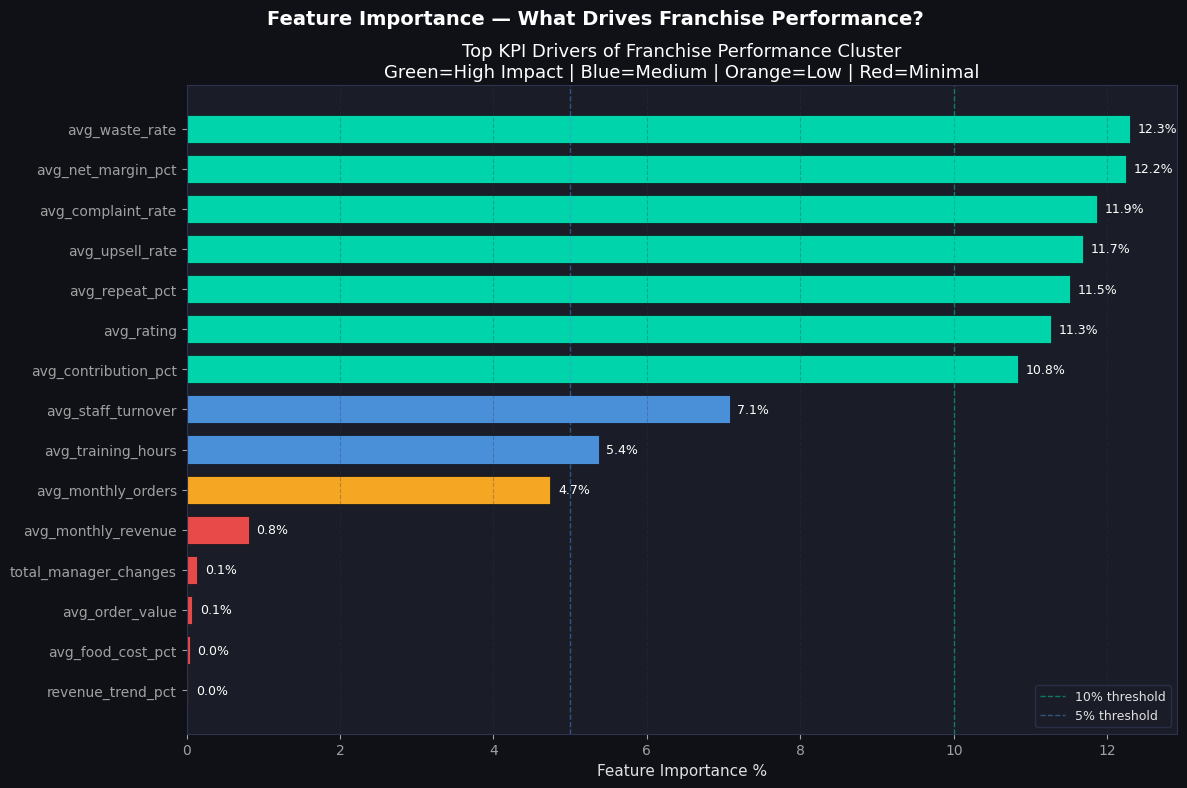


✅ Feature importance chart saved


In [8]:
# ============================================================
# CELL 8 — FEATURE IMPORTANCE VIA RANDOM FOREST
# Which KPIs best predict franchise performance tier?
# ============================================================

from sklearn.ensemble      import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode cluster labels
le = LabelEncoder()
y  = le.fit_transform(outlet_scores['cluster_label'])

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators = 500,
    random_state = 42,
    max_depth    = 6,
    min_samples_leaf = 2
)
rf.fit(X_scaled, y)

# Cross validation score
cv_scores = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
print(f"📊 RANDOM FOREST — CROSS VALIDATION")
print(f"{'='*45}")
print(f"CV Accuracy scores : {cv_scores.round(3)}")
print(f"Mean CV Accuracy   : {cv_scores.mean():.3f}")
print(f"Std CV Accuracy    : {cv_scores.std():.3f}")

# Feature importances
importance_df = pd.DataFrame({
    'feature':   feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).round(4)

print(f"\n📊 FEATURE IMPORTANCE RANKING:")
print(f"{'='*45}")
print(importance_df.to_string(index=False))

# ── Plot: Feature Importance ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Feature Importance — What Drives Franchise Performance?',
             fontsize=14, fontweight='bold', color='white')

importance_sorted = importance_df.sort_values('importance', ascending=True)
colors_imp = ['#00D4AA' if v >= 0.10 else
              '#4A90D9' if v >= 0.05 else
              '#F5A623' if v >= 0.02 else '#E84A4A'
              for v in importance_sorted['importance']]

bars = ax.barh(importance_sorted['feature'],
               importance_sorted['importance'] * 100,
               color=colors_imp,
               edgecolor='#0F1117',
               linewidth=0.5, height=0.7)
for bar, val in zip(bars, importance_sorted['importance'] * 100):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center',
            color='white', fontsize=9)

ax.set_title('Top KPI Drivers of Franchise Performance Cluster\n'
             'Green=High Impact | Blue=Medium | Orange=Low | Red=Minimal',
             color='white')
ax.set_xlabel('Feature Importance %')
ax.axvline(x=10, color='#00D4AA', linestyle='--',
           linewidth=1, alpha=0.5, label='10% threshold')
ax.axvline(x=5,  color='#4A90D9', linestyle='--',
           linewidth=1, alpha=0.5, label='5% threshold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(f'{chart_path}\\chart_15_feature_importance.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("\n✅ Feature importance chart saved")

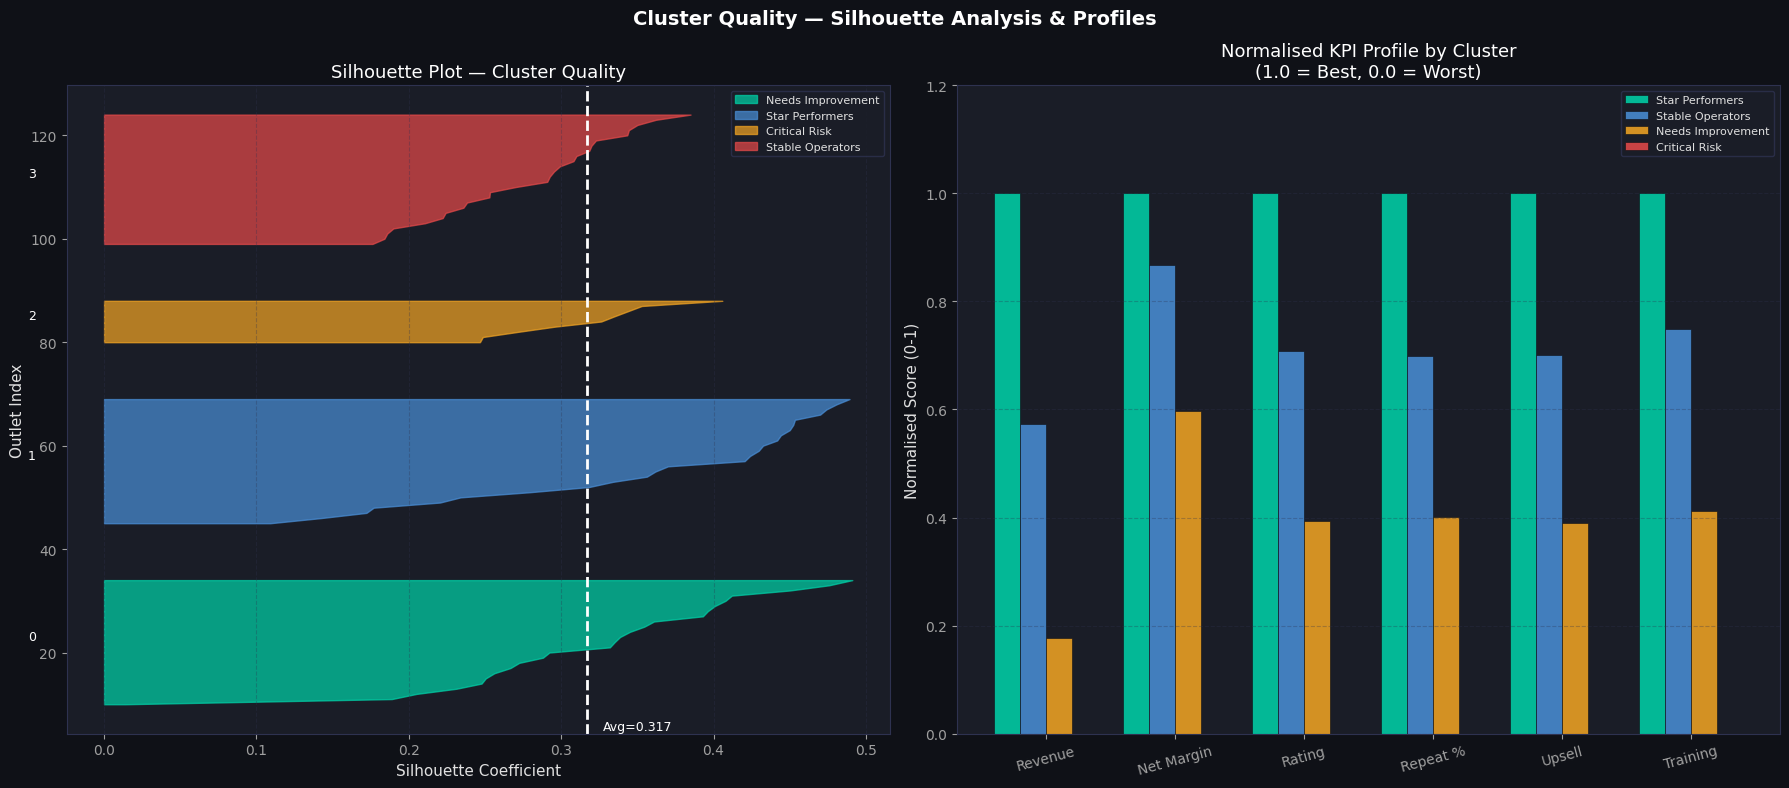

✅ Silhouette & profile chart saved


In [9]:
# ============================================================
# CELL 9 — SILHOUETTE PLOT & CLUSTER PROFILING
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Cluster Quality — Silhouette Analysis & Profiles',
             fontsize=14, fontweight='bold', color='white')

# ── Plot 1: Silhouette Plot ─────────────────────────────────
ax1 = axes[0]
sil_samples  = silhouette_samples(X_scaled, kmeans_final.labels_)
y_lower      = 10
sil_colors   = [CLUSTER_COLORS[i] for i in range(OPTIMAL_K)]

for i in range(OPTIMAL_K):
    cluster_sil = sil_samples[kmeans_final.labels_ == i]
    cluster_sil.sort()
    size_i = cluster_sil.shape[0]
    y_upper = y_lower + size_i
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_sil,
                      alpha=0.7, color=sil_colors[i],
                      label=cluster_label_map[i].split('—')[1].strip())
    ax1.text(-0.05, y_lower + 0.5 * size_i,
             str(i), color='white', fontsize=9)
    y_lower = y_upper + 10

ax1.axvline(x=sil_k4, color='white',
            linestyle='--', linewidth=2)
ax1.text(sil_k4 + 0.01, 5,
         f'Avg={sil_k4:.3f}',
         color='white', fontsize=9)
ax1.set_title('Silhouette Plot — Cluster Quality', color='white')
ax1.set_xlabel('Silhouette Coefficient')
ax1.set_ylabel('Outlet Index')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3, axis='x')

# ── Plot 2: Cluster Radar/Spider Profile ───────────────────
ax2 = axes[1]
profile_cols = [
    'avg_monthly_revenue', 'avg_net_margin_pct',
    'avg_rating',          'avg_repeat_pct',
    'avg_upsell_rate',     'avg_training_hours'
]
profile_labels = [
    'Revenue', 'Net Margin',
    'Rating',  'Repeat %',
    'Upsell',  'Training'
]

# Normalize to 0-1 for radar
profile_data = outlet_scores.groupby('cluster_label')[profile_cols].mean()
profile_norm = (profile_data - profile_data.min()) / (
    profile_data.max() - profile_data.min())

x_pos = np.arange(len(profile_cols))
width = 0.2
for i, (label, color) in enumerate(cluster_color_map.items()):
    if label in profile_norm.index:
        vals = profile_norm.loc[label].values
        ax2.bar(x_pos + i * width, vals,
                width=width, label=label.split('—')[1].strip(),
                color=color, alpha=0.85,
                edgecolor='#0F1117', linewidth=0.5)

ax2.set_title('Normalised KPI Profile by Cluster\n(1.0 = Best, 0.0 = Worst)',
              color='white')
ax2.set_ylabel('Normalised Score (0-1)')
ax2.set_xticks(x_pos + width * 1.5)
ax2.set_xticklabels(profile_labels, rotation=15)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1.2)

plt.tight_layout()
plt.savefig(f'{chart_path}\\chart_16_silhouette_profile.png',
            dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ Silhouette & profile chart saved")

In [11]:
# ============================================================
# CELL 10 — SAVE FINAL ML OUTPUT
# ============================================================

from sklearn.metrics import silhouette_samples

# Add all ML results to outlet_scores
outlet_scores['kmeans_cluster']   = kmeans_final.labels_
outlet_scores['cluster_label']    = outlet_scores['cluster'].map(cluster_label_map)
outlet_scores['pca_component_1']  = pca_2d.fit_transform(X_scaled)[:, 0]
outlet_scores['pca_component_2']  = pca_2d.fit_transform(X_scaled)[:, 1]
outlet_scores['silhouette_score'] = silhouette_samples(X_scaled, kmeans_final.labels_)

# Save final scored file
outlet_scores.to_csv(
    f'{processed_path}\\outlet_scores_final.csv',
    index=False
)

print("✅ Final ML output saved")
print(f"\nFinal file: outlet_scores_final.csv")
print(f"Shape     : {outlet_scores.shape}")

print(f"\n📊 FINAL CLUSTER SUMMARY:")
print("="*65)
summary = outlet_scores.groupby('cluster_label').agg(
    outlets       = ('outlet_id',          'count'),
    avg_score     = ('composite_score',    'mean'),
    avg_revenue   = ('avg_monthly_revenue','mean'),
    avg_margin    = ('avg_net_margin_pct', 'mean'),
    avg_rating    = ('avg_rating',         'mean'),
    avg_complaint = ('avg_complaint_rate', 'mean'),
    avg_repeat    = ('avg_repeat_pct',     'mean'),
    avg_waste     = ('avg_waste_rate',     'mean'),
    avg_turnover  = ('avg_staff_turnover', 'mean'),
).round(2)
print(summary.to_string())

print(f"\n📊 INTERVENTION ACTIONS REQUIRED:")
print(outlet_scores['intervention_action'].value_counts().to_string())

print(f"\n✅ Phase 6 — ML Clustering & PCA COMPLETE")
print(f"Total outlets profiled : {len(outlet_scores)}")
print(f"Clusters identified    : {OPTIMAL_K}")
print(f"Features used          : {len(feature_cols)}")

✅ Final ML output saved

Final file: outlet_scores_final.csv
Shape     : (85, 37)

📊 FINAL CLUSTER SUMMARY:
                               outlets  avg_score  avg_revenue  avg_margin  avg_rating  avg_complaint  avg_repeat  avg_waste  avg_turnover
cluster_label                                                                                                                             
Cluster A — Star Performers         25      86.32    345950.44       18.17        4.28           7.05       56.53      12.90          6.65
Cluster B — Stable Operators        26      63.58    228979.77        3.67        3.94          10.45       50.07      18.53          9.43
Cluster C — Needs Improvement       25      38.49    120638.92      -25.96        3.57          14.34       43.71      24.26         11.74
Cluster D — Critical Risk            9      24.77     71876.89      -91.52        3.10          19.16       35.11      30.90         15.68

📊 INTERVENTION ACTIONS REQUIRED:
intervention_action
LOW 